In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc

In [39]:
genome = 'GRCm38'
ω = 2*np.pi/24

# get gene gtf
infile_gtf = f"../resources/genome/{genome}/gene_annotation.gtf"
gene_gtf = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)
gene_gtf.columns = ['chrom','source','feature','start','end','score','strand','frame','attributes']
# parse the gtf's 9 th column (attributes sep by ;)
attributes = ['gene_id','gene_type','gene_name','transcript_id','transcript_type','transcript_name']
for att in attributes:
    gene_gtf[att] = gene_gtf['attributes'].str.extract(rf'{att} "(.*?)";')


In [79]:


# get extended kalman filter data
bin_size = 1000
infile_kalman = f"../results/{genome}/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
extended = pd.read_csv(infile_kalman, sep='\t')

# get bin phase amplitude
infile_bin_fw = f"../results/{genome}/phase_amp/bin_phase_amp_forward_10000bp.csv"
infile_bin_rv = f"../results/{genome}/phase_amp/bin_phase_amp_reverse_10000bp.csv"
bin_phase_amp = {}
bin_phase_amp['+'] = pd.read_csv(infile_bin_fw, sep='\t')
bin_phase_amp['-'] = pd.read_csv(infile_bin_rv, sep='\t')

# read gene phase amplitude
#infile_gene = f"../results/{genome}/phase_amp/gene_phase_amp.csv"
#gene_phase_amp = {}
#gene_phase_amp['proseq'] = pd.read_csv(infile_gene, sep='\t')



/tmp/ipykernel_320399/625374506.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_320399/625374506.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_320399/625374506.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_320399/625374506.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_320399/625374506.py:146: UserWarn

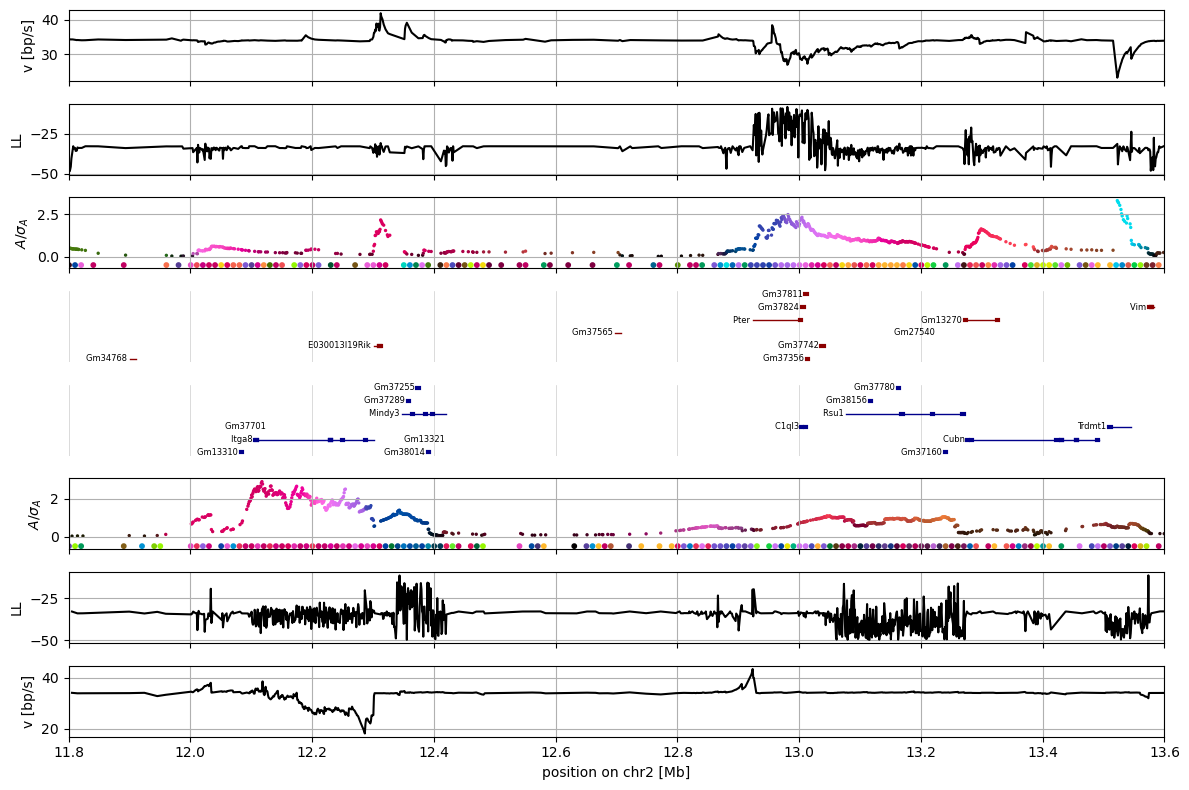

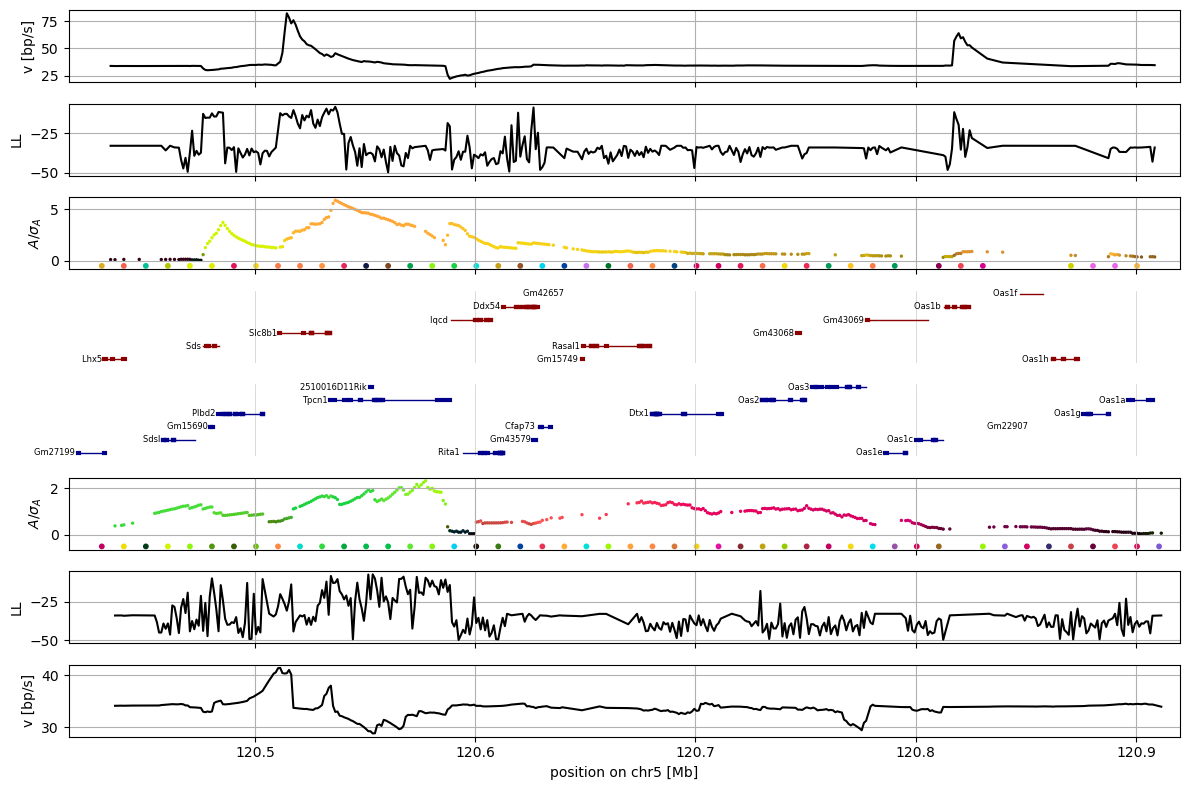

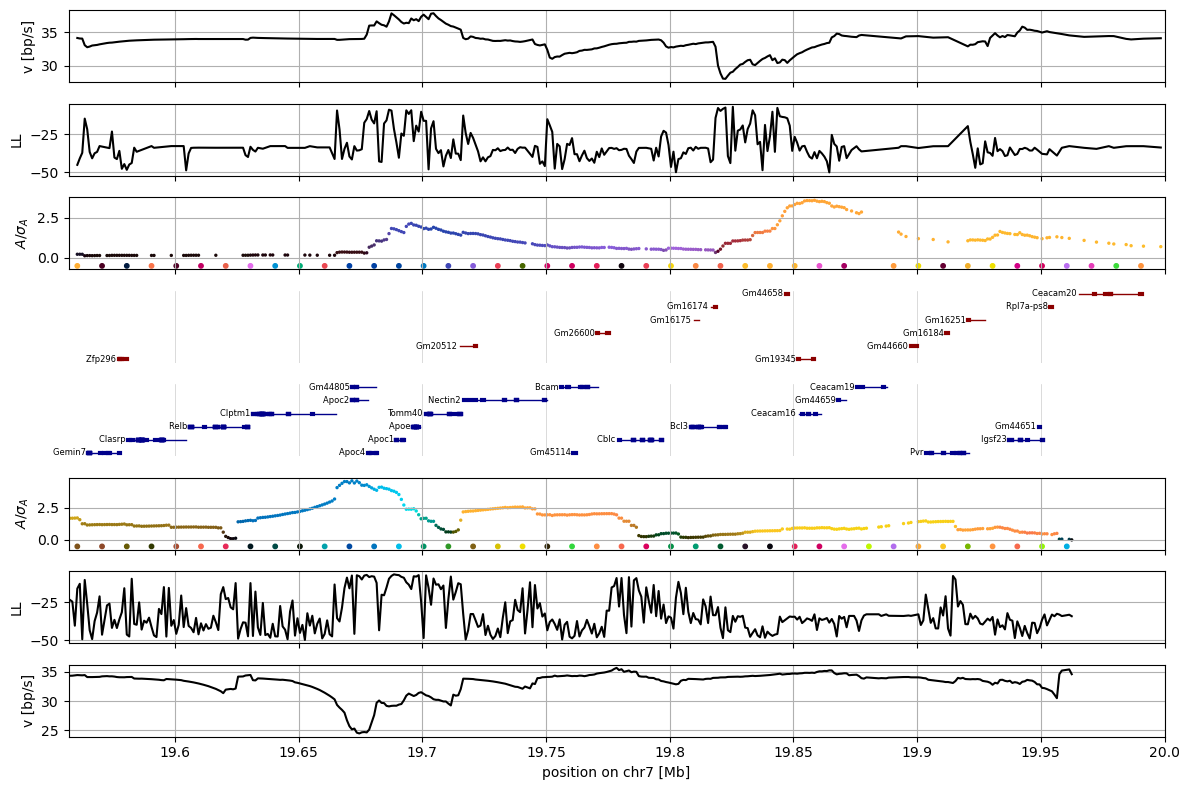

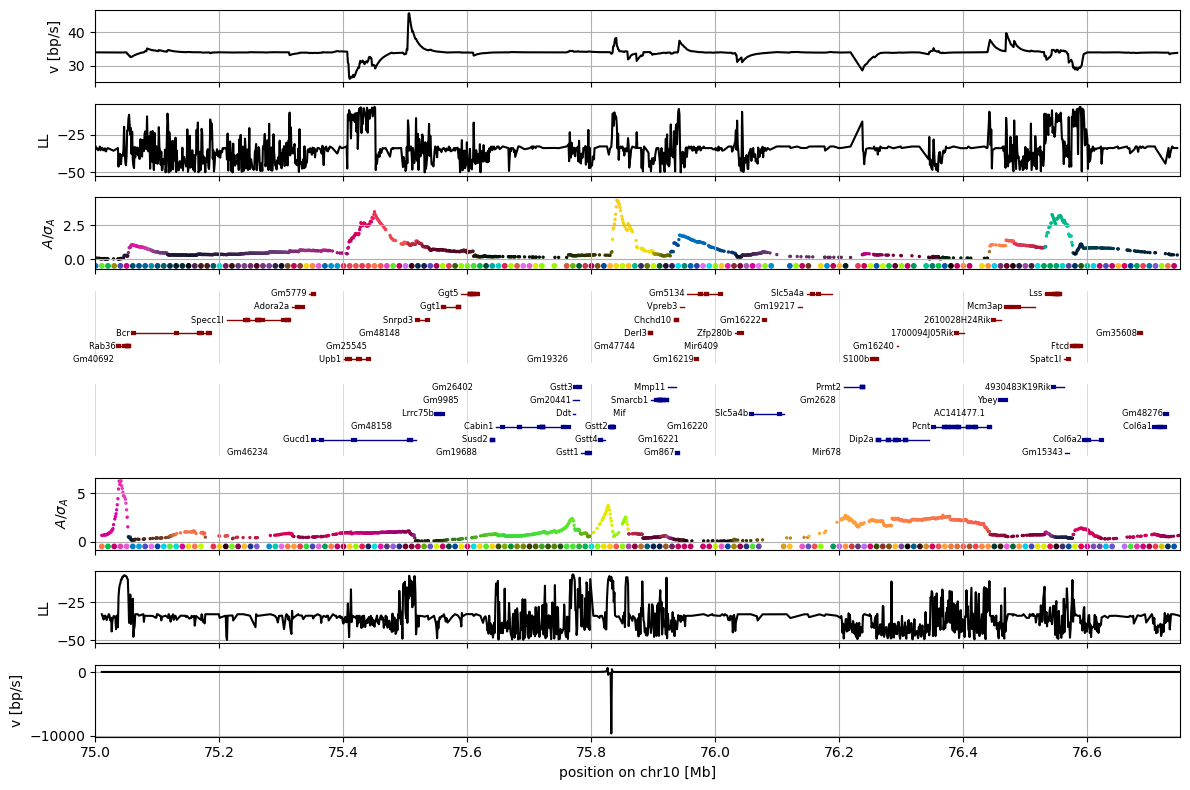

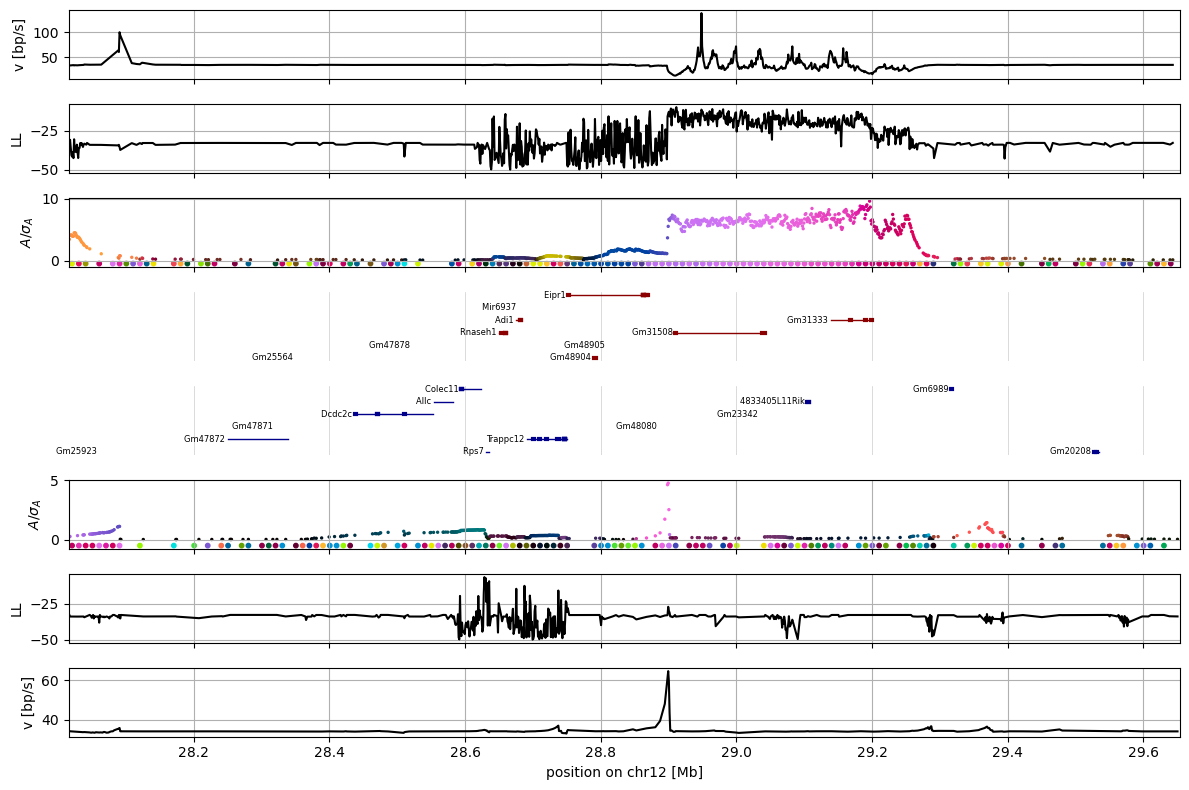

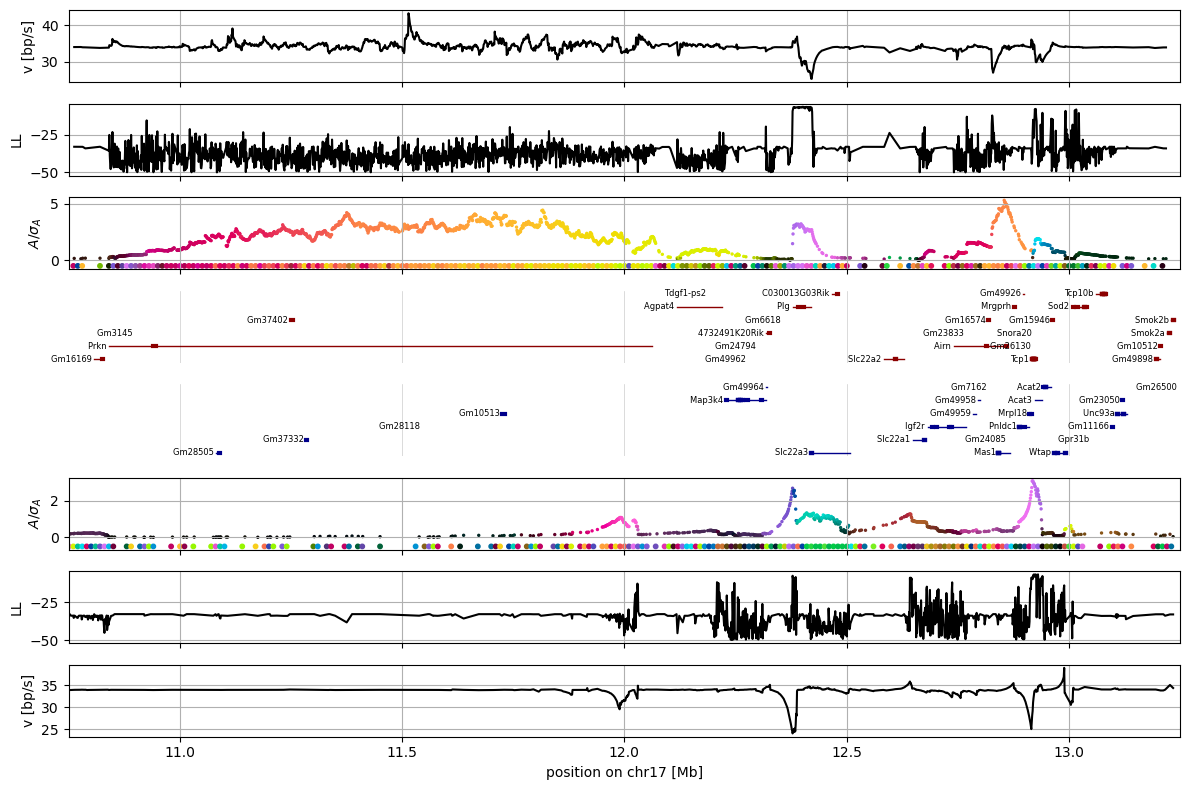

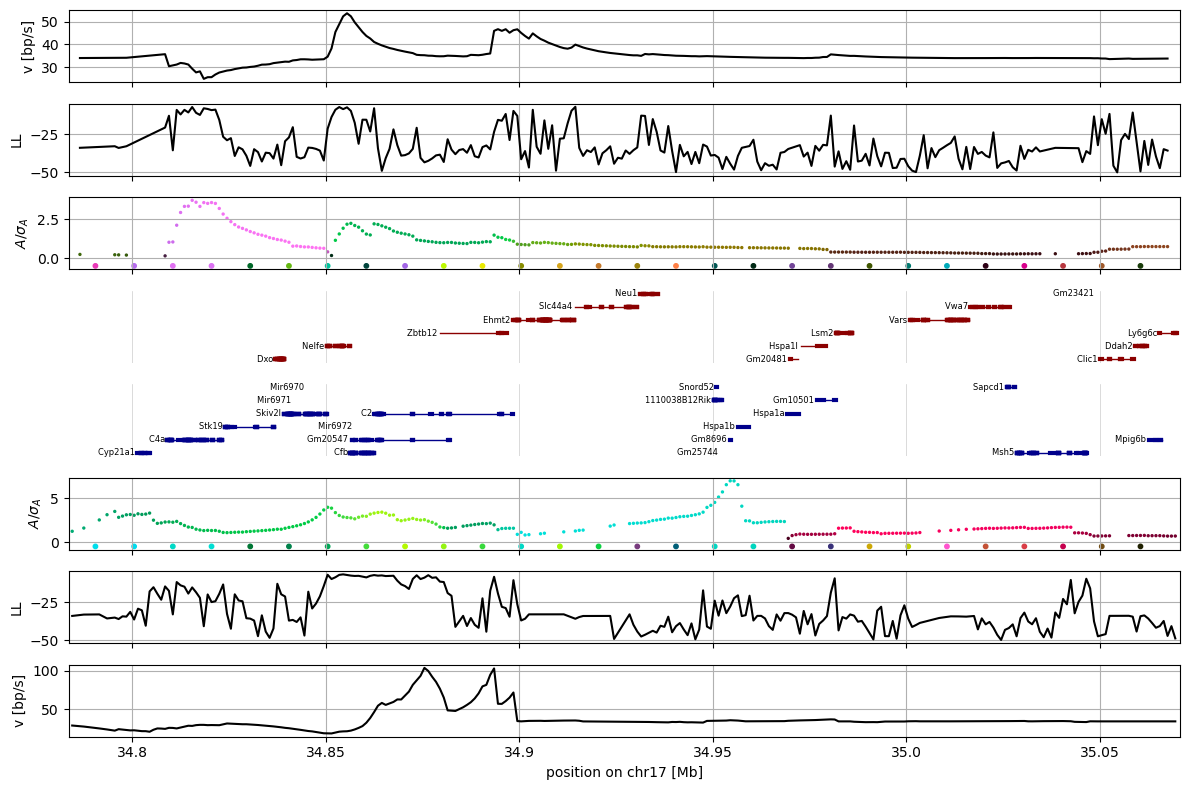

In [80]:
# removed regions :
# 'chr5:104_888_056:107_620_085',
# 'chr5:121_017_471:126_000_000',

Regions = ['chr2:11_800_000:13_600_000',
           'chr5:120_415_452:120_920_000',
           'chr7:19_557_000:20_000_000',
           'chr10:75_000_000:76_750_000',
           'chr12:28015438:29654150',
           'chr17:10_750_000:13_250_000',
           'chr17:34_783_585:35_070_714']
                


for region in Regions:
    chrom, start, end = region.split(':')
    start = int(start)
    end = int(end)
    
    # plot : 2 strands * (k, phase, LL, genes)
    N_tracks = 4
    fig, axes = plt.subplots(nrows=2*N_tracks, ncols=1, figsize=(12, 8))
    fplus = N_tracks-1
    fminus = N_tracks
    for strand in ['+','-']:

        region_data = extended[(extended['chr'] == chrom) & (extended['start'] >= start) & (extended['end'] <= end) & (extended['strand'] == strand)]

        region_gtf = gene_gtf[(gene_gtf['chrom'] == chrom) & (gene_gtf['start'] >= start) & (gene_gtf['end'] <= end) & (gene_gtf['strand'] == strand)]

        x = region_data['start'].values+bin_size/2

        # elongation rate
        k = region_data['k'].values

        # phase
        phi = region_data['phi'].values
        A = region_data['amp'].values
        σ_A = region_data['damp'].values
        col = p2lc(phi,amp=A,th_amp=0.5)

        # bin phase
        x_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['start'].values + bin_size/2
        phi_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['phase'].values        
        amp_bin = bin_phase_amp[strand][(bin_phase_amp[strand]['chr'] == chrom) & (bin_phase_amp[strand]['start'] >= start) & (bin_phase_amp[strand]['end'] <= end)]['amplitude'].values
        col_bin = p2lc(phi_bin,amp=amp_bin,th_amp=0.2)

        # LL
        LL = region_data['LL'].values

        # get genes in region
        genes = region_gtf[(region_gtf['feature'] == 'gene')]['gene_id'].values

        if strand == '+':
            ax = axes[fplus]
            y = 0
            for gene in genes:
                my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
                if len(my_gene) > 0:
                    ax.plot(my_gene[['start','end']].values[0], [y,y], c='darkred', linewidth=1)
                    ax.text(my_gene[['start']].values[0], y, my_gene['gene_name'].values[0]+' ', fontsize=6,ha='right', va='center')

                my_exons = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')]
                for exon in my_exons.iterrows():
                    ax.plot(exon[1][['start','end']].values, [y,y], c='darkred', linewidth=3)
                
                y = (y+1)%6
            ax.set_xlim([start,end])
            for tick in ax.get_xticks():
                ax.axvline(tick, color='k', alpha=0.2, linewidth=0.5)
            ax.set_ylabel('genes')
            ax.axis('off')
            fplus -=1

            ax = axes[fplus]
            ax.scatter(x, A/σ_A, c=col, s=2)
            ax.scatter(x_bin, -.5*np.ones(len(x_bin)), c=col_bin, s=10)
            ax.set_xticklabels([])
            ax.set_xlim([start,end])
            ax.set_ylabel(r'$A/\sigma_A$')
            ax.grid()
            fplus -=1

            ax = axes[fplus]
            ax.plot(x, LL, 'k')
            ax.set_xticklabels([])
            ax.set_xlim([start,end])
            ax.set_ylabel('LL')
            ax.grid()
            fplus -=1

            ax = axes[fplus]
            v = -(ω*1e3)/(k*3600)
            ax.plot(x, v, 'k')
            ax.set_xticklabels([])
            ax.set_xlim([start,end])
            ax.set_ylabel('v [bp/s]')
            ax.grid()
            fplus -=1

        else:
            ax = axes[fminus]
            y = 0
            for gene in genes:

                my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
                if len(my_gene) > 0:
                    ax.plot(my_gene[['start','end']].values[0], [y,y], c='darkblue', linewidth=1)
                    ax.text(my_gene[['start']].values[0], y, my_gene['gene_name'].values[0]+' ', fontsize=6,ha='right', va='center')

                my_exons = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')]
                for exon in my_exons.iterrows():
                    ax.plot(exon[1][['start','end']].values, [y,y], c='darkblue', linewidth=3)
                
                y = (y+1)%6

            ax.set_xlim([start,end])
            for tick in ax.get_xticks():
                ax.axvline(tick, color='k', alpha=0.2, linewidth=0.5)
            ax.axis('off')
            ax.set_ylabel('genes')
            fminus +=1
        
            ax = axes[fminus]
            ax.scatter(x, A/σ_A, c=col, s=2)
            ax.scatter(x_bin, -.5*np.ones(len(x_bin)), c=col_bin, s=10)
            ax.set_xticklabels([])
            ax.grid()
            ax.set_xlim([start,end])
            ax.set_ylabel(r'$A/\sigma_A$')
            fminus += 1

            ax = axes[fminus]
            ax.plot(x, LL, 'k')
            ax.set_xticklabels([])
            ax.set_xlim([start,end])
            ax.set_ylabel('LL')
            ax.grid()
            fminus +=1

            ax = axes[fminus]            
            v = -(ω*1e3)/(k*3600)
            ax.plot(x, v, 'k')
            ax.set_xlim([start,end])
            ax.set_ylabel('v [bp/s]')
            ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
            ax.set_xlabel(f'position on {chrom} [Mb]')
            ax.grid()


    fig.tight_layout()
    fig.savefig(f"fig/extended_kalman/bin{bin_size}bp/{region.replace(':','_')}.pdf")


In [35]:
gene_gtf[(gene_gtf['gene_name'] == 'Apoe') & (gene_gtf['feature'] == 'gene')] 

,chrom,source,feature,start,end,score,strand,frame,attributes,gene_id,gene_type,gene_name,transcript_id,transcript_type,transcript_name
705379,chr7,HAVANA,gene,19696109,19699188,.,-,.,"gene_id ""ENSMUSG00000002985.16""; gene_type ""pr...",ENSMUSG00000002985.16,protein_coding,Apoe,NaN,NaN,NaN


In [142]:
my_gene

,chrom,source,feature,start,end,score,strand,frame,attributes,gene_id,gene_type,gene_name,transcript_id,transcript_type,transcript_name


In [133]:
for gene in genes[:2]:
    my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
    my_exons = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')]

In [136]:
my_exons

,chrom,source,feature,start,end,score,strand,frame,attributes,gene_id,gene_type,gene_name,transcript_id,transcript_type,transcript_name
527373,chr5,HAVANA,exon,106964322,106964425,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000117196.8,protein_coding,Cdc7-203
527374,chr5,HAVANA,exon,106964933,106965114,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000117196.8,protein_coding,Cdc7-203
527377,chr5,HAVANA,exon,106968858,106968941,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000117196.8,protein_coding,Cdc7-203
527379,chr5,HAVANA,exon,106969159,106969294,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000117196.8,protein_coding,Cdc7-203
527381,chr5,HAVANA,exon,106972747,106972840,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000117196.8,protein_coding,Cdc7-203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527525,chr5,HAVANA,exon,106974546,106975192,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000199223.1,lncRNA,Cdc7-208
527527,chr5,HAVANA,exon,106975238,106975660,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000123546.1,retained_intron,Cdc7-205
527528,chr5,HAVANA,exon,106976630,106976712,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000123546.1,retained_intron,Cdc7-205
527529,chr5,HAVANA,exon,106976858,106976963,.,+,.,"gene_id ""ENSMUSG00000029283.17""; transcript_id...",ENSMUSG00000029283.17,protein_coding,Cdc7,ENSMUST00000123546.1,retained_intron,Cdc7-205


In [100]:
exon[1]

chrom                                                           chr2
source                                                        HAVANA
feature                                                         exon
start                                                       13456640
end                                                         13456692
score                                                              .
strand                                                             -
frame                                                              .
attributes         gene_id "ENSMUSG00000026726.10"; transcript_id...
gene_id                                        ENSMUSG00000026726.10
gene_type                                             protein_coding
gene_name                                                       Cubn
transcript_id                                   ENSMUST00000148506.1
transcript_type                                      retained_intron
transcript_name                   